# **PIMA INDIANS DIABETES RISK DECISION-MAKING USING BAYESIAN NETWORK**

INSTALL AND IMPORT LIBRARIES

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn pgmpy

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                            accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, roc_curve)
from sklearn.naive_bayes import GaussianNB

from pgmpy.models import BayesianNetwork, DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator, HillClimbSearch, ExpertKnowledge
from pgmpy.estimators.StructureScore import BIC
from pgmpy.inference import VariableElimination

import missingno as msno
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [ ]:
# Consistent palette for project

# Binary colors (Negative/Positive, 0/1, No-Risk/Risk)
COLOR_NEG = '#3498db'  # Blue (No Diabetes)
COLOR_POS = '#e74c3c'  # Red (Diabetes)
PALETTE_BINARY = [COLOR_NEG, COLOR_POS]

# Neutral color for single-feature distributions
COLOR_HIST = '#3498db' # Blue

# Color for network graph nodes
COLOR_NODE = '#add8e6' # Light Blue

# Colormap for correlation (Diverging)
CMAP_DIVERGING = 'coolwarm' # Red/Blue

# Colormap for feature importance (Sequential)
CMAP_IMPORTANCE = 'viridis'

# Colormap for threshold optimization (Qualitative, distinct lines)
PALETTE_THRESHOLD = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Colormaps for Confusion Matrices
CMAP_CONF_COUNT = 'Blues'
CMAP_CONF_PCT = 'Reds'

DATA LOADING AND INITIAL EXPLORATION

In [ ]:
print("\n" + "="*80)
print("1. DATA LOADING AND INITIAL EXPLORATION")
print("="*80)

df = pd.read_csv('/content/diabetes.csv')

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


1. DATA LOADING AND INITIAL EXPLORATION
Dataset loaded: 768 rows, 9 columns


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print("="*70)
print("DATASET OVERVIEW")
print("="*70)
print(f"\nShape: {df.shape[0]} samples, {df.shape[1]} features\n")

print("Column Datatype Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Variable Distribution:")
print(df['Outcome'].value_counts())
print("\nClass Proportions:")
print(df['Outcome'].value_counts(normalize=True) * 100)

DATASET OVERVIEW

Shape: 768 samples, 9 features

Column Datatype Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Statistical Summary:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.0000

DATA QUALITY ANALYSIS

In [ ]:
print("\n" + "="*80)
print("2. DATA QUALITY ANALYSIS")
print("="*80)

# Check missing values
print("\nMissing Values Check:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Percentage', ascending=False)

if len(missing_df) > 0:
    print(missing_df)
    msno.matrix(df)
    plt.title('Missing Value Pattern', fontsize=14, fontweight='bold')
    plt.show()
else:
    print("No missing values found.")

# Check duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")
if duplicates > 0:
    print(f"   Removing {duplicates} duplicate rows...")
    df = df.drop_duplicates()

# Check for zeros in features where zero is physiologically impossible
zero_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("\nZeros in features (likely missing values):")
for feature in zero_features:
    zero_count = (df[feature] == 0).sum()
    zero_pct = (zero_count / len(df)) * 100
    print(f"  {feature:25s}: {zero_count:3d} ({zero_pct:5.2f}%)")

# Data type summary
print("\nData Types Summary:")
print(df.dtypes.value_counts())


2. DATA QUALITY ANALYSIS

Missing Values Check:
No missing values found.

Duplicate Rows: 0

Zeros in features (likely missing values):
  Glucose                  :   5 ( 0.65%)
  BloodPressure            :  35 ( 4.56%)
  SkinThickness            : 227 (29.56%)
  Insulin                  : 374 (48.70%)
  BMI                      :  11 ( 1.43%)

Data Types Summary:
int64      7
float64    2
Name: count, dtype: int64


EXPLORATORY DATA ANALYSIS (EDA)


3. EXPLORATORY DATA ANALYSIS


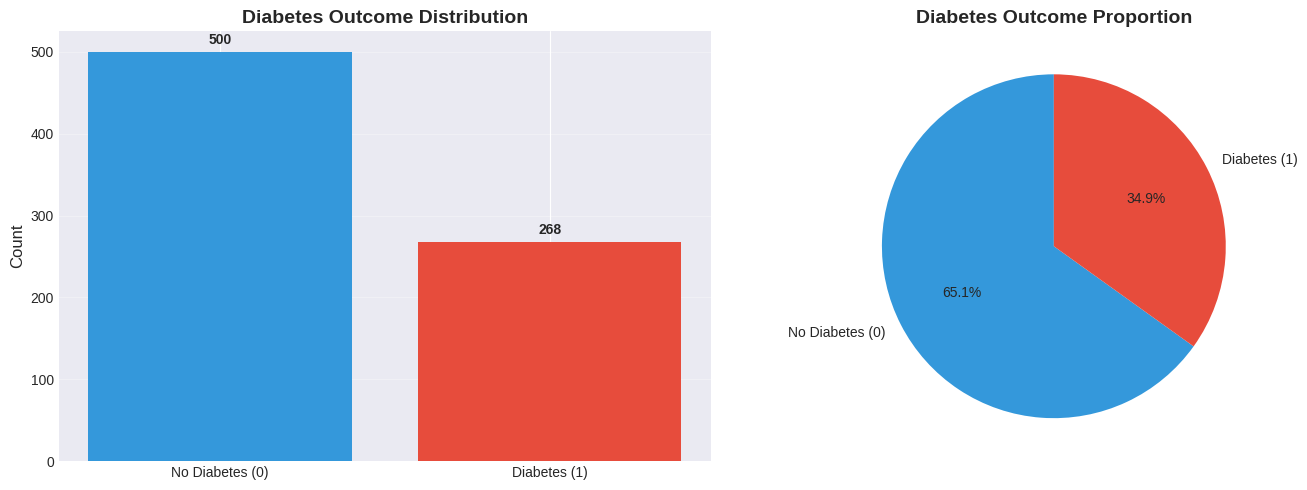

In [ ]:
print("\n" + "="*80)
print("3. EXPLORATORY DATA ANALYSIS")
print("="*80)

# Target Variable Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

target_counts = df['Outcome'].value_counts()
axes[0].bar(['No Diabetes (0)', 'Diabetes (1)'], target_counts.values, color=PALETTE_BINARY)
axes[0].set_title('Diabetes Outcome Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=['No Diabetes (0)', 'Diabetes (1)'],
            autopct='%1.1f%%', colors=PALETTE_BINARY, startangle=90)
axes[1].set_title('Diabetes Outcome Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('01_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

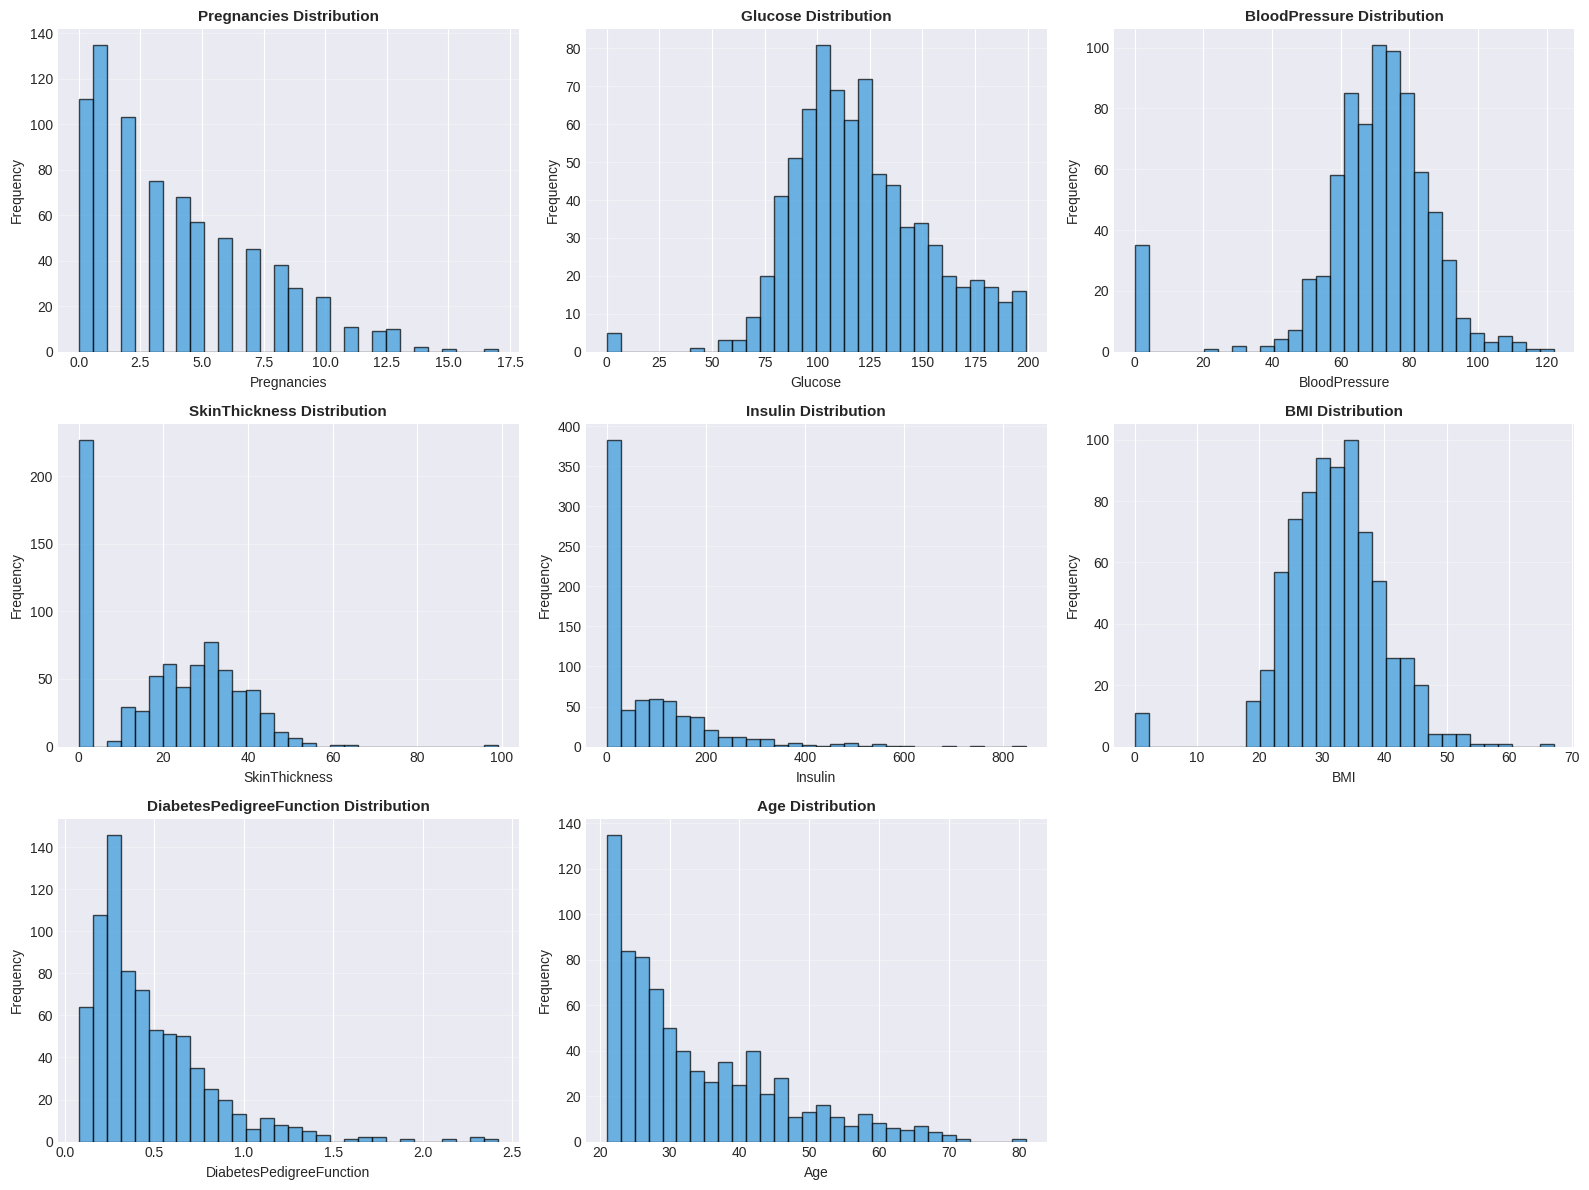

In [ ]:
# Feature Distributions
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(features):
    axes[idx].hist(df[col], bins=30, color=COLOR_HIST, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col} Distribution', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

# Remove empty subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig('02_feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

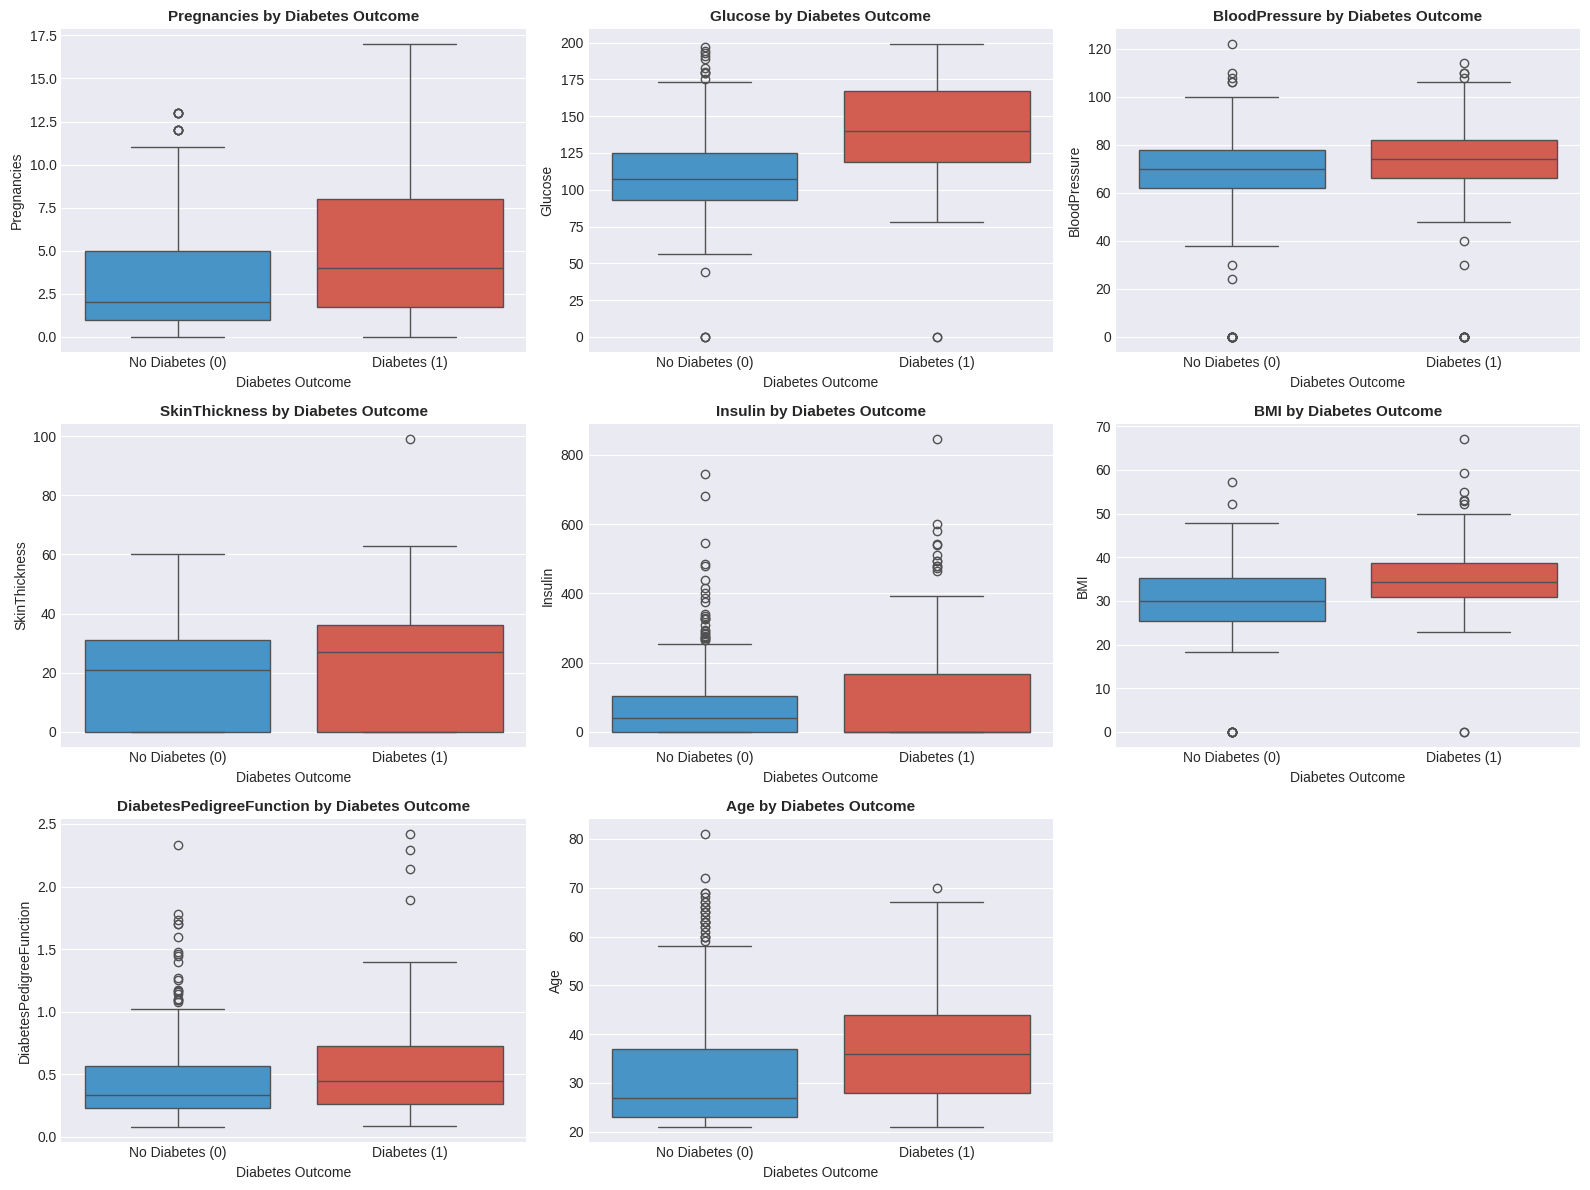

In [ ]:
# Box plots by outcome
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(features):
    sns.boxplot(x='Outcome', y=col, data=df, ax=axes[idx], palette=PALETTE_BINARY)

    axes[idx].set_title(f'{col} by Diabetes Outcome',
                        fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Diabetes Outcome', fontsize=10)
    axes[idx].set_ylabel(col, fontsize=10)
    axes[idx].set_xticklabels(['No Diabetes (0)', 'Diabetes (1)'])

fig.delaxes(axes[-1])
plt.tight_layout()
plt.savefig('03_boxplots_by_outcome.png', dpi=300, bbox_inches='tight')
plt.show()

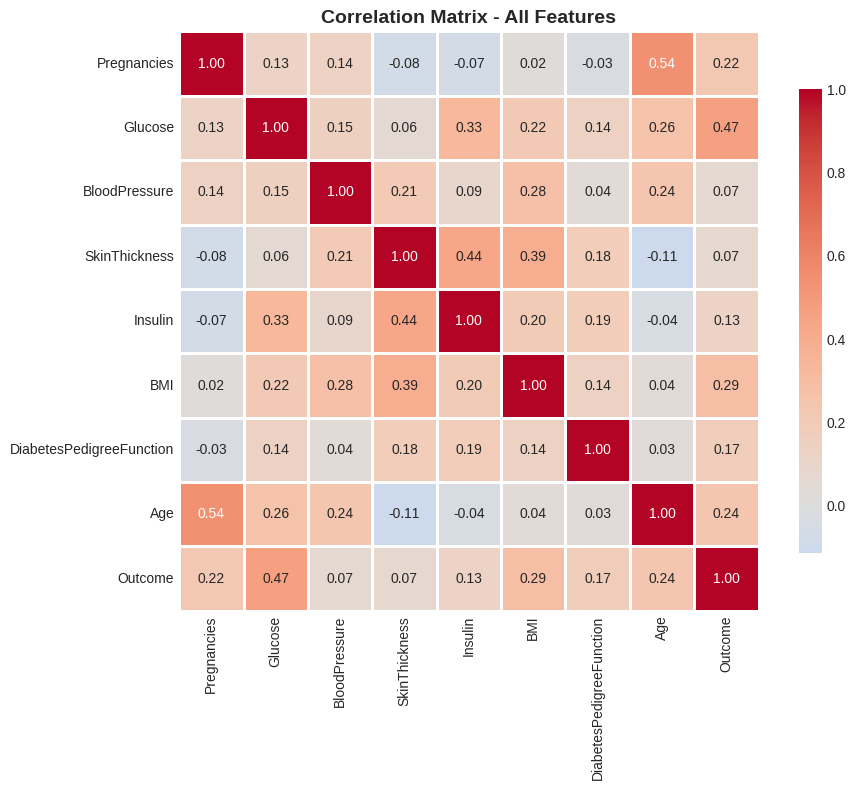

In [ ]:
# Correlation Analysis
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap=CMAP_DIVERGING,
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


Correlation with Outcome:
Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


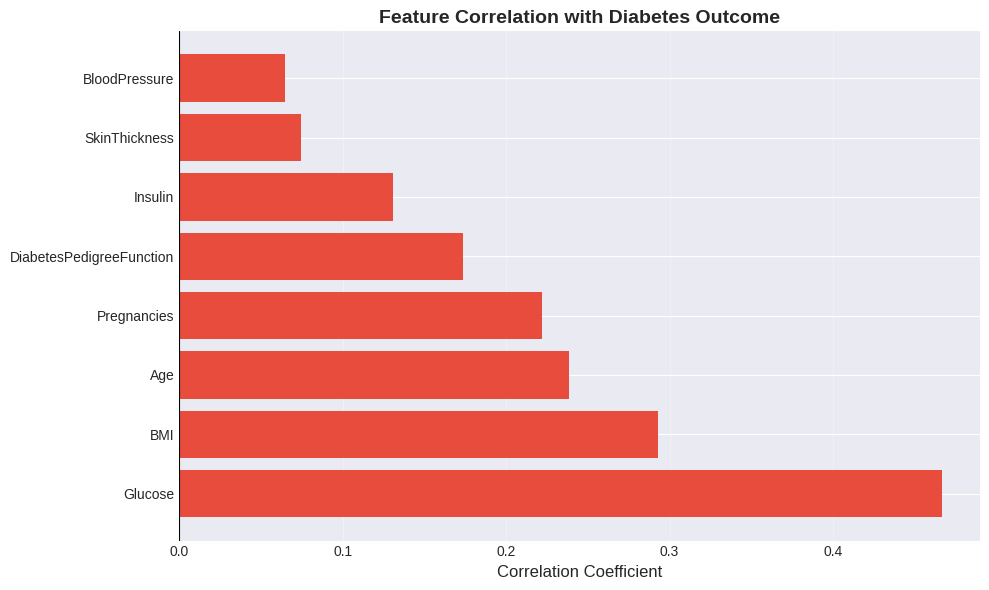

In [ ]:
# Correlation with target
target_correlation = correlation_matrix['Outcome'].sort_values(ascending=False)
print("\nCorrelation with Outcome:")
print(target_correlation)

plt.figure(figsize=(10, 6))

# Drop 'Outcome' for a cleaner plot
target_corr_features = target_correlation.drop('Outcome')

# Assign colors based on positive (Risk) or negative (No Risk)
colors = [COLOR_POS if x > 0 else COLOR_NEG for x in target_corr_features.values]

plt.barh(target_corr_features.index, target_corr_features.values, color=colors)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.title('Feature Correlation with Diabetes Outcome', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('04a_target_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Strong inter-feature correlations
print("\nStrong Inter-Feature Correlations (|r| > 0.3):")

strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.3:
            strong_corr.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j],
                'BN_Implication': 'Potential edge or common parent'
            })

strong_corr_df = pd.DataFrame(strong_corr).sort_values('Correlation', key=abs, ascending=False)
print(strong_corr_df.head(20).to_string(index=False))


Strong Inter-Feature Correlations (|r| > 0.3):
    Feature 1 Feature 2  Correlation                  BN_Implication
  Pregnancies       Age     0.544341 Potential edge or common parent
      Glucose   Outcome     0.466581 Potential edge or common parent
SkinThickness   Insulin     0.436783 Potential edge or common parent
SkinThickness       BMI     0.392573 Potential edge or common parent
      Glucose   Insulin     0.331357 Potential edge or common parent



Importance of Features:
                 Feature  Importance
                 Glucose    0.253759
                     BMI    0.168634
                     Age    0.137739
DiabetesPedigreeFunction    0.122831
           BloodPressure    0.090251
             Pregnancies    0.084101
                 Insulin    0.075526
           SkinThickness    0.067159


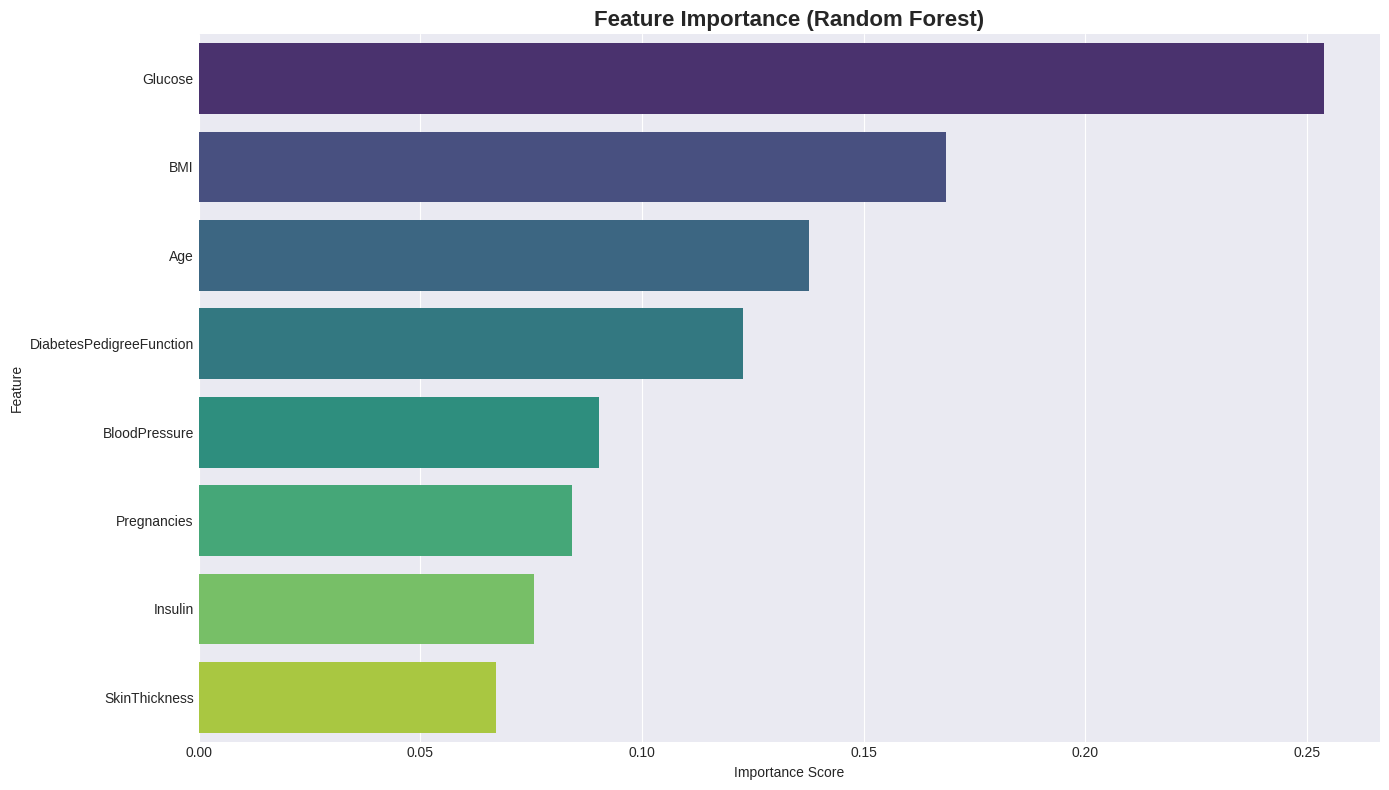

In [ ]:
# Feature Importance Analysis Using Random Forest

# Prepare data for Random Forest
X = df.drop('Outcome', axis=1).copy()
y = df['Outcome']
X = X.fillna(X.median())

# Train Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Get feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nImportance of Features:")
print(importance_df.head(8).to_string(index=False))

# Visualize
plt.figure(figsize=(14, 8))
top_features = importance_df.head(15)
sns.barplot(data=top_features, x='Importance', y='Feature', palette=CMAP_IMPORTANCE) # MODIFIED
plt.title('Feature Importance (Random Forest)', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('05_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

DATA PREPROCESSING

In [ ]:
print("\n" + "="*80)
print("4. DATA PREPROCESSING")
print("="*80)

# Create a copy for preprocessing
df_processed = df.copy()

# Handle zeros as missing values for specific features
print("\nHandling zeros as missing values...")

for feature in zero_features:
    # Calculate the median for Outcome = 0 (No Diabetes)
    median_0 = df_processed[
        (df_processed[feature] != 0) & (df_processed['Outcome'] == 0)
    ][feature].median()

    # Calculate the median for Outcome = 1 (Diabetes)
    median_1 = df_processed[
        (df_processed[feature] != 0) & (df_processed['Outcome'] == 1)
    ][feature].median()

    print(f"  {feature}:")
    print(f"    - Median for 'No Diabetes' (0): {median_0:.2f}")
    print(f"    - Median for 'Diabetes' (1):   {median_1:.2f}")

    # Get the count of zeros for logging
    zero_count_0 = ((df_processed[feature] == 0) & (df_processed['Outcome'] == 0)).sum()
    zero_count_1 = ((df_processed[feature] == 0) & (df_processed['Outcome'] == 1)).sum()

    # Apply the conditional imputation
    df_processed.loc[
        (df_processed[feature] == 0) & (df_processed['Outcome'] == 0),
        feature
    ] = median_0

    df_processed.loc[
        (df_processed[feature] == 0) & (df_processed['Outcome'] == 1),
        feature
    ] = median_1

    print(f"    - Replaced {zero_count_0} zeros for 'No Diabetes' group.")
    print(f"    - Replaced {zero_count_1} zeros for 'Diabetes' group.")

# Check to confirm no zeros are left in the columns
print("\nVerifying no zeros remain in key features:")
for feature in zero_features:
    zero_count = (df_processed[feature] == 0).sum()
    print(f"   {feature:25s}: {zero_count} zeros")

print("\nPreprocessing with conditional imputation completed!")


4. DATA PREPROCESSING

Handling zeros as missing values...
  Glucose:
    - Median for 'No Diabetes' (0): 107.00
    - Median for 'Diabetes' (1):   140.00
    - Replaced 3 zeros for 'No Diabetes' group.
    - Replaced 2 zeros for 'Diabetes' group.
  BloodPressure:
    - Median for 'No Diabetes' (0): 70.00
    - Median for 'Diabetes' (1):   74.50
    - Replaced 19 zeros for 'No Diabetes' group.
    - Replaced 16 zeros for 'Diabetes' group.
  SkinThickness:
    - Median for 'No Diabetes' (0): 27.00
    - Median for 'Diabetes' (1):   32.00
    - Replaced 139 zeros for 'No Diabetes' group.
    - Replaced 88 zeros for 'Diabetes' group.
  Insulin:
    - Median for 'No Diabetes' (0): 102.50
    - Median for 'Diabetes' (1):   169.50
    - Replaced 236 zeros for 'No Diabetes' group.
    - Replaced 138 zeros for 'Diabetes' group.
  BMI:
    - Median for 'No Diabetes' (0): 30.10
    - Median for 'Diabetes' (1):   34.30
    - Replaced 9 zeros for 'No Diabetes' group.
    - Replaced 2 zeros for 'D

FEATURE DISCRETIZATION FOR BAYESIAN NETWORK

In [ ]:
print("\n" + "="*80)
print("5. FEATURE DISCRETIZATION")
print("="*80)

df_discrete = df_processed.copy()

# Discretize continuous features based on medical/statistical thresholds

# Age: Standard age groups
df_discrete['Age'] = pd.cut(df_discrete['Age'],
                            bins=[0, 30, 40, 50, 100],
                            labels=['Young', 'Middle', 'Senior', 'Elderly'])

# Pregnancies: Group by frequency
df_discrete['Pregnancies'] = pd.cut(df_discrete['Pregnancies'],
                                   bins=[-1, 0, 3, 6, 20],
                                   labels=['None', 'Low', 'Medium', 'High'])

# Glucose: Based on diabetes diagnosis thresholds
df_discrete['Glucose'] = pd.cut(df_discrete['Glucose'],
                               bins=[0, 100, 125, 200],
                               labels=['Normal', 'Prediabetes', 'Diabetes'])

# Blood Pressure: Clinical categories
df_discrete['BloodPressure'] = pd.cut(df_discrete['BloodPressure'],
                                     bins=[0, 80, 90, 200],
                                     labels=['Normal', 'Elevated', 'High'])

# BMI: WHO categories
df_discrete['BMI'] = pd.cut(df_discrete['BMI'],
                           bins=[0, 18.5, 25, 30, 100],
                           labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

# Skin Thickness: Cut with explicit bins to avoid duplicate issues
skin_thickness_bins = [0, 20, 30, 100]
df_discrete['SkinThickness'] = pd.cut(df_discrete['SkinThickness'],
                                     bins=skin_thickness_bins,
                                     labels=['Low', 'Medium', 'High'],
                                     include_lowest=True)

# Insulin: Cut with explicit bins
insulin_bins = [0, 100, 200, 900]
df_discrete['Insulin'] = pd.cut(df_discrete['Insulin'],
                               bins=insulin_bins,
                               labels=['Low', 'Medium', 'High'],
                               include_lowest=True)

# Diabetes Pedigree Function: Percentiles with fallback
try:
    df_discrete['DiabetesPedigreeFunction'] = pd.qcut(
        df_discrete['DiabetesPedigreeFunction'],
        q=3,
        labels=['Low', 'Medium', 'High'],
        duplicates='drop'
    )
except ValueError:
    dpf_bins = [0, 0.3, 0.6, 3.0]
    df_discrete['DiabetesPedigreeFunction'] = pd.cut(
        df_discrete['DiabetesPedigreeFunction'],
        bins=dpf_bins,
        labels=['Low', 'Medium', 'High'],
        include_lowest=True
    )

print("\nDiscretization complete!")

print("\nSample of discretized data:")
print(df_discrete.head(10))

print("\nDiscretized feature statistics:")
for col in df_discrete.columns:
    print(f"  {col:30s}: {df_discrete[col].nunique()} unique values")



5. FEATURE DISCRETIZATION

Discretization complete!

Sample of discretized data:
  Pregnancies      Glucose BloodPressure SkinThickness Insulin         BMI  \
0      Medium     Diabetes        Normal          High  Medium       Obese   
1         Low       Normal        Normal        Medium  Medium  Overweight   
2        High     Diabetes        Normal          High  Medium      Normal   
3         Low       Normal        Normal        Medium     Low  Overweight   
4        None     Diabetes        Normal          High  Medium       Obese   
5      Medium  Prediabetes        Normal        Medium  Medium  Overweight   
6         Low       Normal        Normal          High     Low       Obese   
7        High  Prediabetes        Normal        Medium  Medium       Obese   
8         Low     Diabetes        Normal          High    High       Obese   
9        High  Prediabetes          High          High  Medium       Obese   

  DiabetesPedigreeFunction      Age  Outcome  
0           

TRAIN-TEST SPLIT


6. TRAIN-TEST SPLIT

Training set size: 614 (79.9%)
Test set size: 154 (20.1%)

Target distribution in training set:
Outcome
0    400
1    214
Name: count, dtype: int64

Target distribution in test set:
Outcome
0    100
1     54
Name: count, dtype: int64


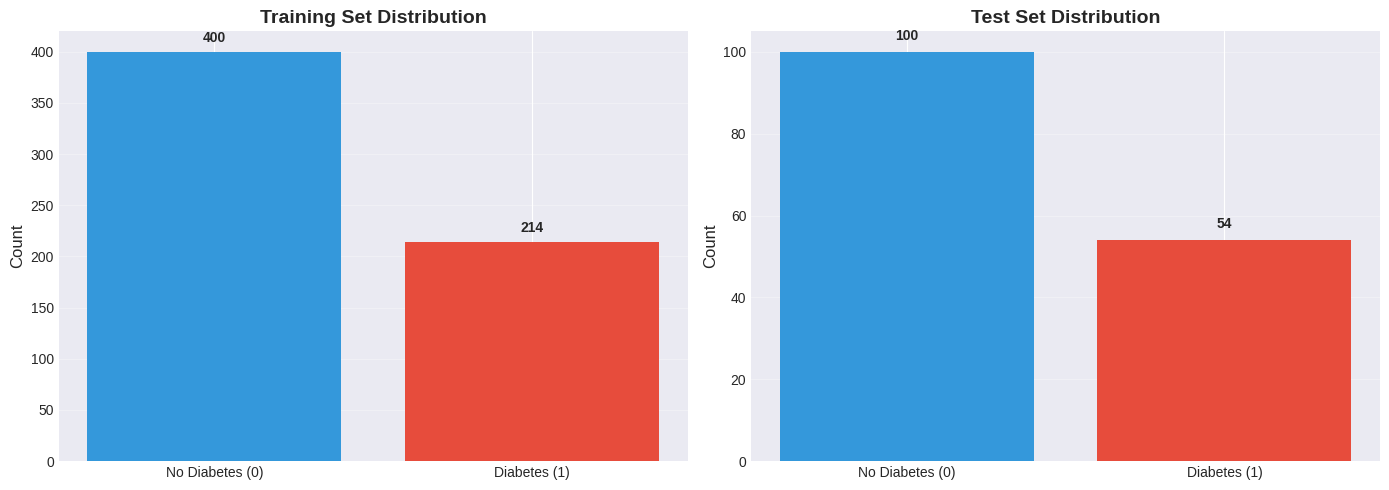

In [ ]:
print("\n" + "="*80)
print("6. TRAIN-TEST SPLIT")
print("="*80)

# Convert all to string for pgmpy
for col in df_discrete.columns:
    df_discrete[col] = df_discrete[col].astype(str)

# Separate features and target
X = df_discrete.drop('Outcome', axis=1)
y = df_discrete['Outcome']

# Split with stratification and a fixed random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=24,
    stratify=y
)

print(f"\nTraining set size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

print("\nTarget distribution in training set:")
train_counts = y_train.value_counts().sort_index()
print(train_counts)

print("\nTarget distribution in test set:")
test_counts = y_test.value_counts().sort_index()
print(test_counts)

# Visualize split
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ['No Diabetes (0)', 'Diabetes (1)']
axes[0].bar(labels, train_counts.values, color=PALETTE_BINARY)
axes[0].set_title('Training Set Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

test_counts = y_test.value_counts().sort_index()
axes[1].bar(labels, test_counts.values, color=PALETTE_BINARY)
axes[1].set_title('Test Set Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(test_counts.values):
    axes[1].text(i, v + 3, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('06_train_test_split.png', dpi=300, bbox_inches='tight')
plt.show()

BAYESIAN NETWORK MODEL CONSTRUCTION


7. BAYESIAN NETWORK MODEL CONSTRUCTION (with Structure Learning)

Defining graph priors (blacklist and whitelist)...

FORBIDDEN EDGES (Blacklist):
   BMI -> Age
   Pregnancies -> Age
   SkinThickness -> BMI

MEDICALLY VALID EDGES (Whitelist/Fixed):
   Glucose -> Outcome
   BMI -> Outcome
   Pregnancies -> Outcome
   BloodPressure -> Outcome
   Age -> Pregnancies
   BMI -> SkinThickness

Searching for the best model structure using data-informed priors...


  0%|          | 0/500 [00:00<?, ?it/s]


LEARNED NETWORK STRUCTURE (SUMMARY)

Total Nodes: 9
Nodes: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Total Edges: 11

Root Nodes (no incoming edges):
   Insulin, BMI

Parent-Child Relationships (Edges):
   Pregnancies -> Outcome
   Glucose -> Outcome, BloodPressure
   BloodPressure -> Outcome
   Insulin -> Glucose, Age
   BMI -> SkinThickness, Outcome
   Age -> Pregnancies
   Outcome -> SkinThickness, DiabetesPedigreeFunction

NETWORK VISUALIZATION
Generating network plot...


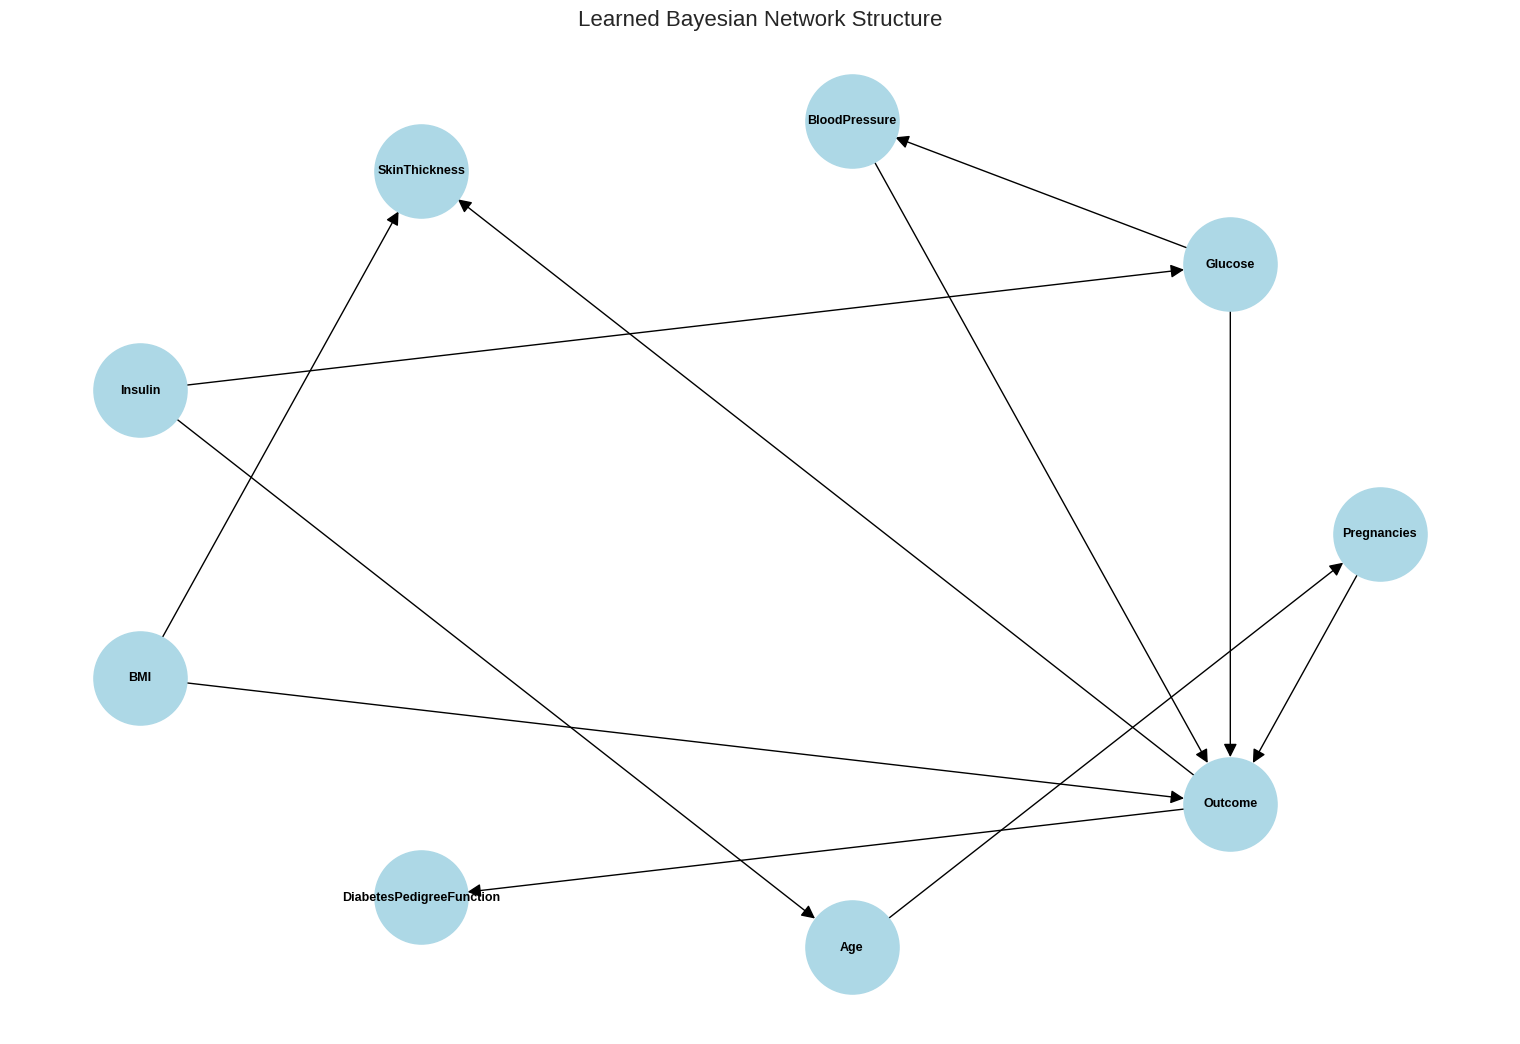



MODEL FITTING

Fitting Bayesian Network to the learned structure...

Model fitting completed successfully!


In [ ]:
print("\n" + "="*80)
print("7. BAYESIAN NETWORK MODEL CONSTRUCTION (with Structure Learning)")
print("="*80)

# Combine train data
train_data = pd.concat([X_train, y_train], axis=1)

# Scoring method
bic = BIC(data=train_data)

print("\nDefining graph priors (blacklist and whitelist)...")

# 1. Blacklist: Edges that are impossible
# Banning other non-causal links.
blacklist = [
    ('BMI', 'Age'),
    ('Pregnancies', 'Age'),
    ('SkinThickness', 'BMI')
]

# 2. Whitelist (Fixed Edges): Edges that must be in the graph
# Forcing the medically known, primary risk factors to point to Outcome.
whitelist = [
    ('Glucose', 'Outcome'),
    ('BMI', 'Outcome'),
    ('Pregnancies', 'Outcome'),
    ('BloodPressure','Outcome'),
    ('Age', 'Pregnancies'),
    ('BMI', 'SkinThickness'),
]

print("\nFORBIDDEN EDGES (Blacklist):")
for edge in blacklist: print(f"   {edge[0]} -> {edge[1]}")

print("\nMEDICALLY VALID EDGES (Whitelist/Fixed):")
for edge in whitelist: print(f"   {edge[0]} -> {edge[1]}")

expert_knowledge = ExpertKnowledge(
    forbidden_edges=blacklist,
    required_edges=whitelist
)

# Search algorithm
print("\nSearching for the best model structure using data-informed priors...")
hc = HillClimbSearch(data=train_data)

best_model_structure = hc.estimate(
    scoring_method=bic,
    max_iter=500,
    tabu_length=50,
    expert_knowledge=expert_knowledge
)

print("\n" + "="*80)
print("LEARNED NETWORK STRUCTURE (SUMMARY)")
print("="*80)

print(f"\nTotal Nodes: {len(best_model_structure.nodes())}")
print(f"Nodes: {list(best_model_structure.nodes())}")
print(f"\nTotal Edges: {len(best_model_structure.edges())}")
all_children = set([child for parent, child in best_model_structure.edges()])
root_nodes = [node for node in best_model_structure.nodes() if node not in all_children]
print(f"\nRoot Nodes (no incoming edges):")
print(f"   {', '.join(root_nodes)}")

parents_dict = {}
for parent, child in best_model_structure.edges():
    if parent not in parents_dict:
        parents_dict[parent] = []
    parents_dict[parent].append(child)

print(f"\nParent-Child Relationships (Edges):")
for parent, children in parents_dict.items():
    print(f"   {parent} -> {', '.join(children)}")

print("\n" + "="*80)
print("NETWORK VISUALIZATION")
print("="*80)

try:
    print("Generating network plot...")

    plt.figure(figsize=(15, 10))
    pos = nx.kamada_kawai_layout(best_model_structure)

    nx.draw(
        best_model_structure,
        with_labels=True,
        node_size=4500,
        node_color=COLOR_NODE,
        font_size=9,
        font_weight='bold',
        pos=pos,
        arrows=True,
        arrowstyle='-|> ',
        arrowsize=20
    )

    plt.title("Learned Bayesian Network Structure", fontsize=16)
    plt.savefig('07_bayesian_network_structure.png', dpi=300, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"\nError during visualization: {e}")
    print("Please ensure 'networkx' and 'matplotlib' are installed.")

# Create and fit the model
model = DiscreteBayesianNetwork(best_model_structure.edges())

print("\n\n" + "="*80)
print("MODEL FITTING")
print("="*80)
print("\nFitting Bayesian Network to the learned structure...")
model.fit(train_data, estimator=BayesianEstimator, prior_type="BDeu")
print("\nModel fitting completed successfully!")

USE_PGMPY = True

MODEL EVALUATION

In [ ]:
print("\n" + "="*80)
print("8. MODEL EVALUATION")
print("="*80)

if USE_PGMPY:
    print("\nMaking predictions with Bayesian Network...")
    inference = VariableElimination(model)

    predictions_proba = []
    predictions = []

    for idx in range(len(X_test)):
        if idx % 50 == 0:
            print(f"  Processed {idx}/{len(X_test)} samples...")

        evidence = {}
        for col in X_test.columns:
            val = X_test.iloc[idx][col]
            if pd.notna(val):
                evidence[col] = str(val)

        try:
            result = inference.query(
                variables=['Outcome'],
                evidence=evidence,
                show_progress=False
            )
            proba = result.values[1] if len(result.values) > 1 else result.values[0]
            predictions_proba.append(proba)
            predictions.append('1' if proba >= 0.5 else '0')
        except:
            predictions_proba.append(0.5)
            predictions.append('0')

    predictions_proba = np.array(predictions_proba)
    predictions = np.array(predictions)

else:
    predictions_proba = model.predict_proba(X_test)[:, 1]
    predictions = model.predict(X_test).astype(str)

# Convert to int for metrics
y_test_int = y_test.astype(int).values
predictions_int = np.array([int(p) for p in predictions])

# Calculate metrics
accuracy = accuracy_score(y_test_int, predictions_int)
precision = precision_score(y_test_int, predictions_int, zero_division=0)
recall = recall_score(y_test_int, predictions_int, zero_division=0)
f1 = f1_score(y_test_int, predictions_int, zero_division=0)
roc_auc = roc_auc_score(y_test_int, predictions_proba)

print(f"\n{'='*50}")
print("MODEL PERFORMANCE ON TEST SET")
print(f"{'='*50}")
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
print(f"ROC-AUC:   {roc_auc:.4f} ({roc_auc*100:.2f}%)")



8. MODEL EVALUATION

Making predictions with Bayesian Network...
  Processed 0/154 samples...
  Processed 50/154 samples...
  Processed 100/154 samples...
  Processed 150/154 samples...

MODEL PERFORMANCE ON TEST SET
Accuracy:  0.7987 (79.87%)
Precision: 0.6885 (68.85%)
Recall:    0.7778 (77.78%)
F1-Score:  0.7304 (73.04%)
ROC-AUC:   0.8432 (84.32%)


THRESHOLD OPTIMIZATION


9. THRESHOLD OPTIMIZATION

Optimal Threshold: 0.55
F1-Score at optimal threshold: 0.7339


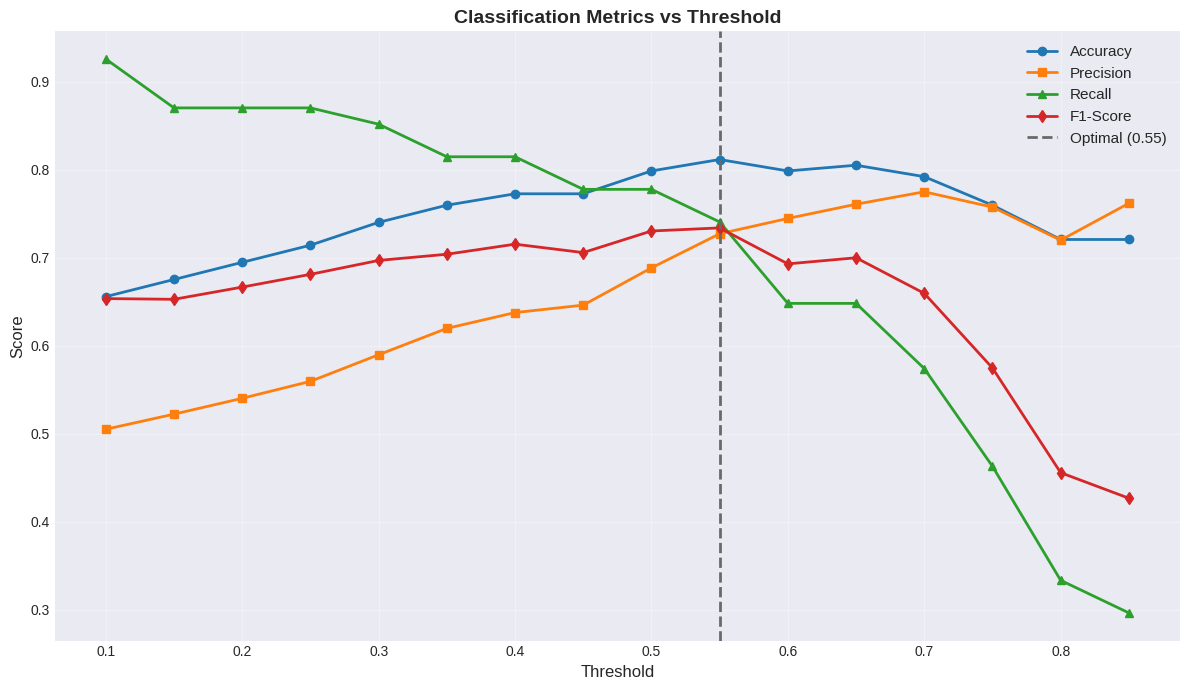

In [ ]:
print("\n" + "="*80)
print("9. THRESHOLD OPTIMIZATION")
print("="*80)

thresholds = np.arange(0.1, 0.9, 0.05)
metrics_by_threshold = []

for threshold in thresholds:
    y_pred = (predictions_proba >= threshold).astype(int)

    acc = accuracy_score(y_test_int, y_pred)
    prec = precision_score(y_test_int, y_pred, zero_division=0)
    rec = recall_score(y_test_int, y_pred, zero_division=0)
    f1_t = f1_score(y_test_int, y_pred, zero_division=0)

    metrics_by_threshold.append({
        'threshold': threshold,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1_t
    })

metrics_df = pd.DataFrame(metrics_by_threshold)
optimal_idx = metrics_df['f1_score'].idxmax()
optimal_threshold = metrics_df.loc[optimal_idx, 'threshold']

print(f"\nOptimal Threshold: {optimal_threshold:.2f}")
print(f"F1-Score at optimal threshold: {metrics_df.loc[optimal_idx, 'f1_score']:.4f}")

plt.figure(figsize=(12, 7))
plt.plot(metrics_df['threshold'], metrics_df['accuracy'],
         marker='o', label='Accuracy', linewidth=2, color=PALETTE_THRESHOLD[0])
plt.plot(metrics_df['threshold'], metrics_df['precision'],
         marker='s', label='Precision', linewidth=2, color=PALETTE_THRESHOLD[1])
plt.plot(metrics_df['threshold'], metrics_df['recall'],
         marker='^', label='Recall', linewidth=2, color=PALETTE_THRESHOLD[2])
plt.plot(metrics_df['threshold'], metrics_df['f1_score'],
         marker='d', label='F1-Score', linewidth=2, color=PALETTE_THRESHOLD[3])
plt.axvline(x=optimal_threshold, color='dimgray', linestyle='--', linewidth=2, # Changed from red
            label=f'Optimal ({optimal_threshold:.2f})')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Classification Metrics vs Threshold', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('08_threshold_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

CONFUSION MATRIX


10. CONFUSION MATRIX


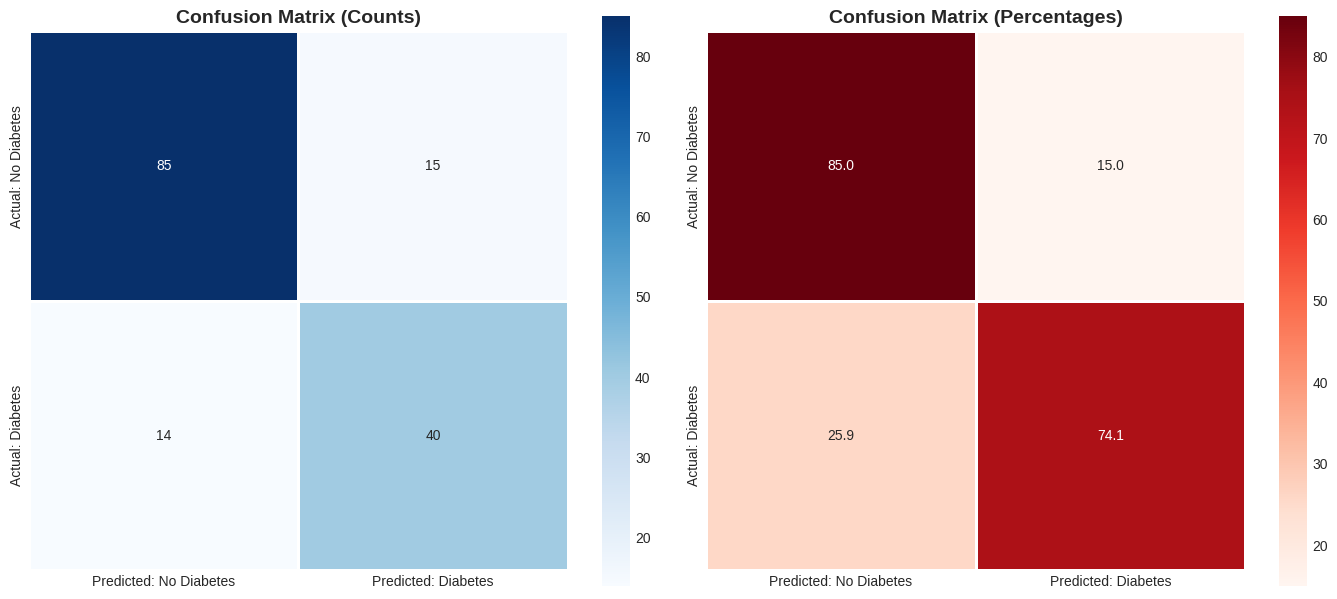


Confusion Matrix Components:
   True Negatives:  85
   False Positives: 15
   False Negatives: 14
   True Positives:  40


In [ ]:
print("\n" + "="*80)
print("10. CONFUSION MATRIX")
print("="*80)

y_pred_optimal = (predictions_proba >= optimal_threshold).astype(int)
cm = confusion_matrix(y_test_int, y_pred_optimal)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Absolute counts
sns.heatmap(cm, annot=True, fmt='d', cmap=CMAP_CONF_COUNT, ax=axes[0], # MODIFIED
            square=True, linewidths=2,
            xticklabels=['Predicted: No Diabetes', 'Predicted: Diabetes'],
            yticklabels=['Actual: No Diabetes', 'Actual: Diabetes'])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

# Percentages
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap=CMAP_CONF_PCT, ax=axes[1], # MODIFIED
            square=True, linewidths=2,
            xticklabels=['Predicted: No Diabetes', 'Predicted: Diabetes'],
            yticklabels=['Actual: No Diabetes', 'Actual: Diabetes'])
axes[1].set_title('Confusion Matrix (Percentages)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('09_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Components:")
print(f"   True Negatives:  {tn}")
print(f"   False Positives: {fp}")
print(f"   False Negatives: {fn}")
print(f"   True Positives:  {tp}")

In [ ]:
print("\n" + "="*60)
print("ERROR ANALYSIS")
print("="*60)

# Create a Results DataFrame
results_df = pd.DataFrame({
    'Actual': y_test_int,
    'Predicted': y_pred_optimal,
    'Probability': predictions_proba
})

# Define Full Error Types
def get_error_type(row):
    if row['Actual'] == 1 and row['Predicted'] == 1:
        return 'True Positive'
    if row['Actual'] == 0 and row['Predicted'] == 0:
        return 'True Negative'
    if row['Actual'] == 1 and row['Predicted'] == 0:
        return 'False Negative'
    if row['Actual'] == 0 and row['Predicted'] == 1:
        return 'False Positive'
    return 'Other'

results_df['Error_Type'] = results_df.apply(get_error_type, axis=1)

# Using Continuous Features for the Test Set
continuous_features_test = df_processed.drop('Outcome', axis=1).loc[X_test.index].reset_index(drop=True)

# Merge Results with Continuous Features
error_analysis_df = pd.concat([results_df, continuous_features_test], axis=1)

print(f"Total Test Samples: {len(error_analysis_df)}")
print(error_analysis_df['Error_Type'].value_counts())

# Analyze False Negatives (Missed Diabetics)
key_features = ['Glucose', 'BMI', 'Age', 'Pregnancies', 'Probability']
fn_samples = error_analysis_df[error_analysis_df['Error_Type'] == 'False Negative']
tp_samples = error_analysis_df[error_analysis_df['Error_Type'] == 'True Positive']

print("\n" + "-"*60)
print("ANALYSIS: MISSED DIABETICS (False Negatives)")
print("-"*60)
if len(fn_samples) > 0:
    print("Profile of patients we MISSED:")
    print(fn_samples[key_features].describe())
    print("\nProfile of patients we CAUGHT (True Positives):")
    print(tp_samples[key_features].describe())
else:
    print("No False Negatives! (Perfect Recall)")

# Analyze False Positives (Incorrectly Flagged)
fp_samples = error_analysis_df[error_analysis_df['Error_Type'] == 'False Positive']
tn_samples = error_analysis_df[error_analysis_df['Error_Type'] == 'True Negative']

print("\n" + "-"*60)
print("ANALYSIS: INCORRECTLY FLAGGED (False Positives)")
print("-"*60)
if len(fp_samples) > 0:
    print("Profile of healthy patients we FLAGGED:")
    print(fp_samples[key_features].describe())
    print("\nProfile of healthy patients we CORRECTLY IGNORED (True Negatives):")
    print(tn_samples[key_features].describe())
else:
    print("No False Positives! (Perfect Precision)")


ERROR ANALYSIS
Total Test Samples: 154
Error_Type
True Negative     85
True Positive     40
False Positive    15
False Negative    14
Name: count, dtype: int64

------------------------------------------------------------
ANALYSIS: MISSED DIABETICS (False Negatives)
------------------------------------------------------------
Profile of patients we MISSED:
          Glucose        BMI        Age  Pregnancies  Probability
count   14.000000  14.000000  14.000000    14.000000    14.000000
mean   120.785714  33.307143  40.071429     4.357143     0.251164
std     33.337848   7.443992  14.317629     2.239751     0.180614
min     78.000000  25.100000  26.000000     0.000000     0.001280
25%     96.250000  29.125000  28.250000     3.000000     0.105206
50%    113.500000  31.800000  36.000000     4.500000     0.215480
75%    142.250000  34.975000  48.250000     6.000000     0.419377
max    195.000000  55.000000  70.000000     8.000000     0.536160

Profile of patients we CAUGHT (True Positives

ROC CURVE


11. ROC CURVE


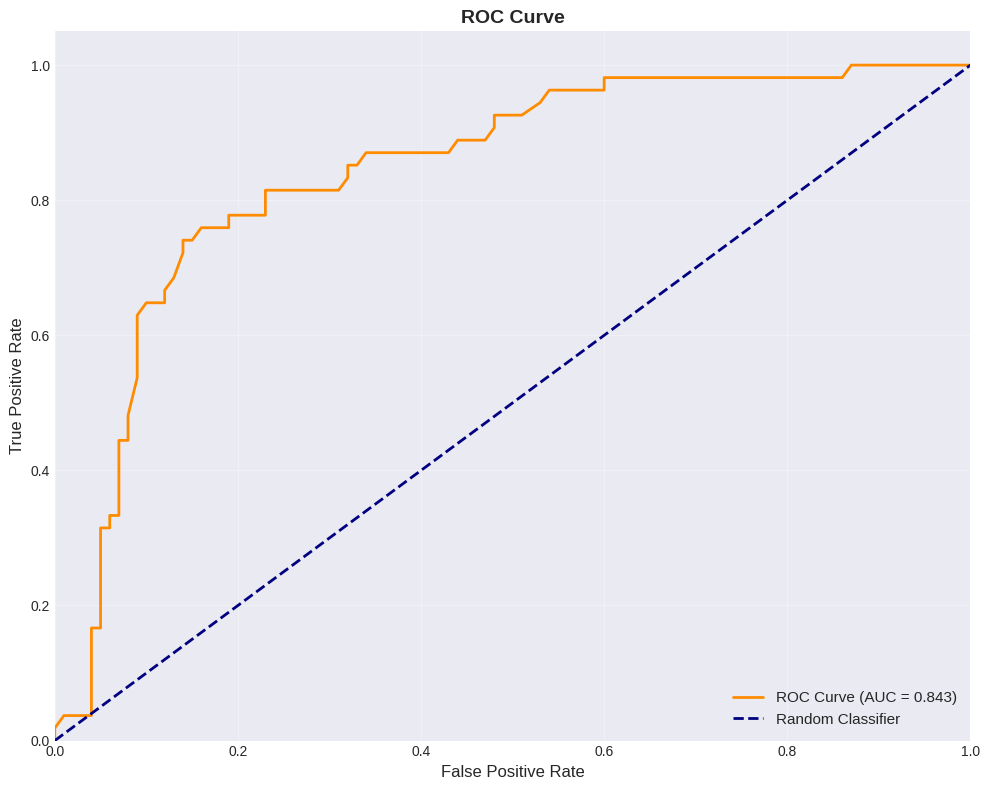

In [ ]:
print("\n" + "="*80)
print("11. ROC CURVE")
print("="*80)

fpr, tpr, _ = roc_curve(y_test_int, predictions_proba)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('10_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

MODEL COMPARISON


12. MODEL COMPARISON
Training 3 baseline models on numeric data...

Baseline models trained.

Model Performance Comparison:
                      ROC-AUC  F1-Score  Accuracy
Random Forest        0.945926  0.844037  0.889610
SVM                  0.905185  0.800000  0.850649
Bayesian Network     0.843241  0.730435  0.798701
Logistic Regression  0.856481  0.660000  0.779221


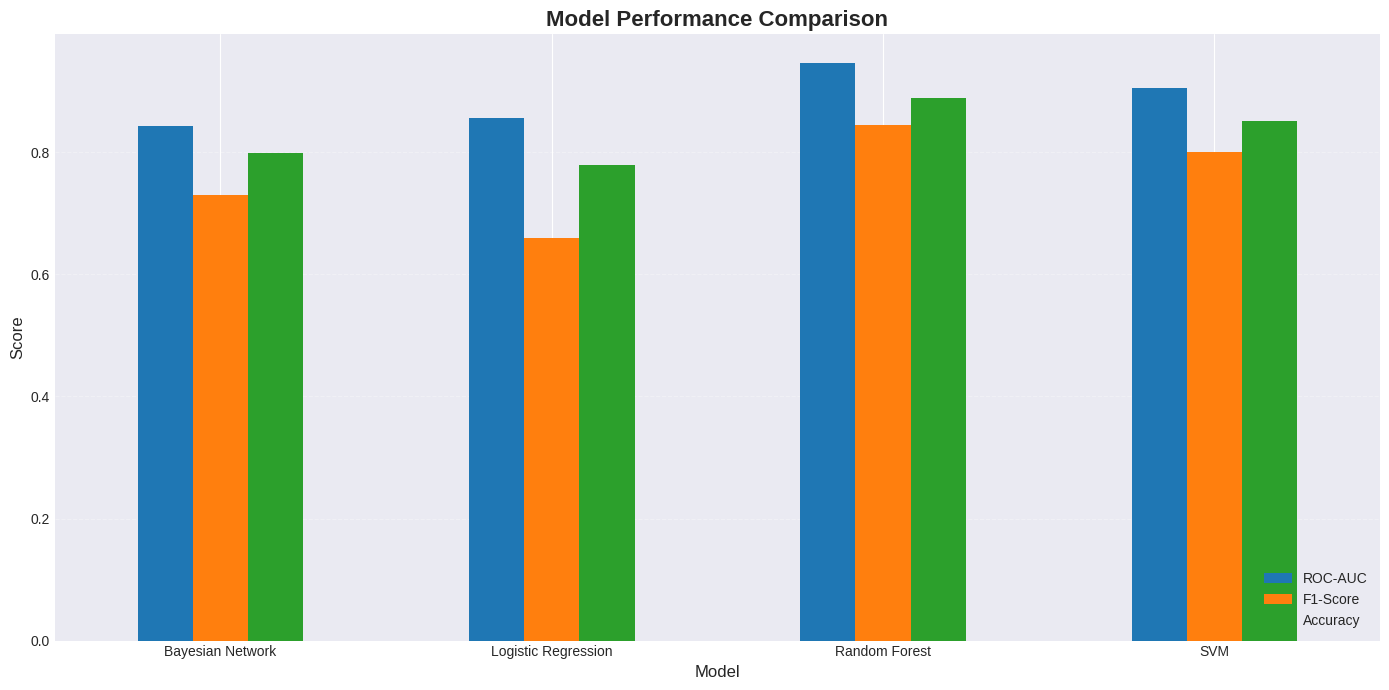

In [ ]:
print("\n" + "="*80)
print("12. MODEL COMPARISON")
print("="*80)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Prepare Data for Sklearn Models
X_numeric = df_processed.drop('Outcome', axis=1)
y_numeric = df_processed['Outcome']

# Use the same stratification for a fair comparison
X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(
    X_numeric, y_numeric,
    test_size=0.2,
    random_state=24,
    stratify=y_numeric
)

print(f"Training 3 baseline models on numeric data...")

# Train Logistic Regression
lr = LogisticRegression(random_state=24, max_iter=1000)
lr.fit(X_train_num, y_train_num)
lr_pred = lr.predict(X_test_num)
lr_pred_proba = lr.predict_proba(X_test_num)[:, 1]
lr_acc = accuracy_score(y_test_num, lr_pred)
lr_f1 = f1_score(y_test_num, lr_pred)
lr_roc_auc = roc_auc_score(y_test_num, lr_pred_proba)

# Train Random Forest
rf = RandomForestClassifier(random_state=24)
rf.fit(X_train_num, y_train_num)
rf_pred = rf.predict(X_test_num)
rf_pred_proba = rf.predict_proba(X_test_num)[:, 1]
rf_acc = accuracy_score(y_test_num, rf_pred)
rf_f1 = f1_score(y_test_num, rf_pred)
rf_roc_auc = roc_auc_score(y_test_num, rf_pred_proba)

# Train SVM (Support Vector Machine)
svm = SVC(random_state=24, probability=True)
svm.fit(X_train_num, y_train_num)
svm_pred = svm.predict(X_test_num)
svm_pred_proba = svm.predict_proba(X_test_num)[:, 1]
svm_acc = accuracy_score(y_test_num, svm_pred)
svm_f1 = f1_score(y_test_num, svm_pred)
svm_roc_auc = roc_auc_score(y_test_num, svm_pred_proba)

print("\nBaseline models trained.")

# Build Comparison DataFrame
try:
    models = {
        'Bayesian Network': (roc_auc, f1, accuracy),
        'Logistic Regression': (lr_roc_auc, lr_f1, lr_acc),
        'Random Forest': (rf_roc_auc, rf_f1, rf_acc),
        'SVM': (svm_roc_auc, svm_f1, svm_acc)
    }

    comparison_df = pd.DataFrame(models).T
    comparison_df.columns = ['ROC-AUC', 'F1-Score', 'Accuracy']

    print("\nModel Performance Comparison:")
    print(comparison_df.sort_values(by='F1-Score', ascending=False))

    # Plot Comparison Chart
    ax = comparison_df.plot(
        kind='bar',
        figsize=(14, 7),
        color=PALETTE_THRESHOLD,
        rot=0
    )

    plt.title('Model Performance Comparison', fontsize=16, fontweight='bold')
    plt.ylabel('Score', fontsize=12)
    plt.xlabel('Model', fontsize=12)
    plt.legend(loc='lower right')
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig('11_model_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

except NameError:
    print("\nError: Could not find 'roc_auc', 'f1', or 'accuracy' variables.")
    print("Please ensure the 'MODEL EVALUATION' part has been run.")
except Exception as e:
    print(f"\nAn error occurred during comparison: {e}")

SAVE RESULTS

In [ ]:
print("\n" + "="*80)
print("13. SAVING RESULTS")
print("="*80)

# Save predictions
results_df = pd.DataFrame({
    'Actual': y_test_int,
    'Predicted': y_pred_optimal,
    'Probability': predictions_proba,
    'Correct': (y_test_int == y_pred_optimal).astype(int)
})
results_df.to_csv('pima_predictions.csv', index=False)
print("\nPredictions saved to 'pima_predictions.csv'")

# Save metrics
metrics_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Score': [
        accuracy_score(y_test_int, y_pred_optimal),
        precision_score(y_test_int, y_pred_optimal, zero_division=0),
        recall_score(y_test_int, y_pred_optimal, zero_division=0),
        f1_score(y_test_int, y_pred_optimal, zero_division=0),
        roc_auc
    ]
})
metrics_summary.to_csv('pima_metrics.csv', index=False)
print("Metrics saved to 'pima_metrics.csv'")

print("\n" + "="*80)
print("ANALYSIS COMPLETED")
print("="*80)
print(f"\nFinal Accuracy: {accuracy_score(y_test_int, y_pred_optimal)*100:.2f}%")
print(f"Final ROC-AUC: {roc_auc*100:.2f}%")
print(f"Optimal Threshold: {optimal_threshold:.2f}")
print("="*80)


13. SAVING RESULTS

Predictions saved to 'pima_predictions.csv'
Metrics saved to 'pima_metrics.csv'

ANALYSIS COMPLETED

Final Accuracy: 81.17%
Final ROC-AUC: 84.32%
Optimal Threshold: 0.55
